# Mini-batch Training, Early Stopping, and the Ring MLP

In the previous notebook, we used a small MLP to classify a nonlinear ring-shaped dataset. Here we isolate one optimization choice: **mini-batch size**.

The goal is model selection, not just watching curves for a fixed number of epochs. For each batch size, we train with the same architecture and optimizer, but we select the final model using **early stopping on validation loss**.

The main idea is:

$$
\text{batch size changes the optimization path, and validation loss chooses the checkpoint.}
$$

Small batches use fewer examples per update. Their gradients are noisier, and they perform more updates per pass through the data. Large batches use smoother gradient estimates, but they make fewer updates per epoch. Early stopping lets each run stop when held-out performance stops improving.


## Learning goals

By the end of this notebook you should be able to explain:

1. what a mini-batch is,
2. why different batch sizes produce different optimization paths,
3. why fixed epochs can be misleading for model selection,
4. how early stopping selects the best checkpoint using validation loss,
5. how to compare batch sizes using best validation loss, best validation accuracy, stopping epoch, and total updates.


In [262]:
import math
import random

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

# Reproducibility
seed = 11
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

torch.set_default_dtype(torch.float32)

plt.rcParams.update({
    "figure.figsize": (7.4, 5.0),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print("PyTorch version:", torch.__version__)


PyTorch version: 2.2.2


## The dataset

We use the same kind of synthetic ring dataset as before. Each point has two coordinates. The label is `1` if the point lies inside a noisy annulus, and `0` otherwise.

This is deliberately not linearly separable. A small MLP can solve it, but only by learning a curved decision boundary.


In [263]:
def make_ring_data(n=840, noise=0.08):
    """A simple nonlinear two-class dataset in dimensionless coordinates."""
    X = 2.6 * torch.rand(n, 2) - 1.3
    r = torch.sqrt((X ** 2).sum(dim=1))
    y = ((r > 0.55) & (r < 1.05)).float()
    X = X + noise * torch.randn_like(X)
    return X, y


X_ring, y_ring = make_ring_data()

validation_fraction = 0.20
split_generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(X_ring), generator=split_generator)
n_validation = int(validation_fraction * len(indices))
validation_indices = indices[:n_validation]
train_indices = indices[n_validation:]

X_train, y_train = X_ring[train_indices], y_ring[train_indices]
X_val, y_val = X_ring[validation_indices], y_ring[validation_indices]

print(f"Training points:   {len(X_train)}")
print(f"Validation points: {len(X_val)}")


Training points:   672
Validation points: 168


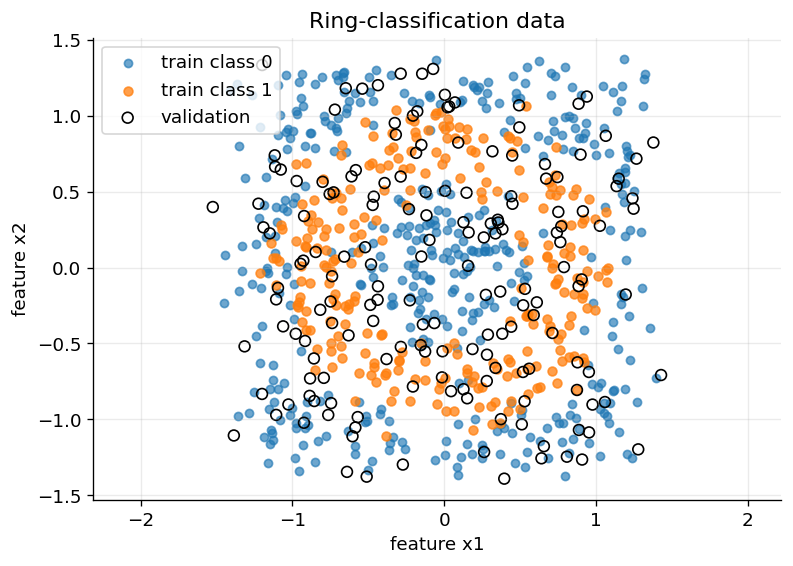

In [264]:
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], s=24, alpha=0.65, label="train class 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], s=28, alpha=0.75, label="train class 1")
plt.scatter(X_val[:, 0], X_val[:, 1], s=42, facecolors="none", edgecolors="black", linewidths=1.0, label="validation")
plt.xlabel("feature x1")
plt.ylabel("feature x2")
plt.title("Ring-classification data")
plt.axis("equal")
plt.legend(loc="best")
plt.show()


## Mini-batch size changes the number of updates

Suppose the training set has $N$ examples.

- **Full-batch training** uses all $N$ training examples for every gradient update.
- **Mini-batch training** uses a smaller batch, such as 16, 32, or 64 examples, for each update.
- **Stochastic training** is the extreme case where the batch size is 1.

Batch size changes two things at once:

1. the noise level of each gradient estimate,
2. the number of parameter updates per epoch.

If the training set has $N$ examples, then approximately

$$
\text{updates per epoch} = \left\lceil \frac{N}{\text{batch size}} \right\rceil.
$$


In [265]:
batch_sizes = [8, 16, 32, 64, 128, None]
labels = {None: "full batch"}

print("batch size     updates per epoch")
print("----------     -----------------")
for batch_size in batch_sizes:
    label = labels.get(batch_size, str(batch_size))
    effective_batch_size = len(X_train) if batch_size is None else batch_size
    updates_per_epoch = math.ceil(len(X_train) / effective_batch_size)
    print(f"{label:>10s}     {updates_per_epoch:>17d}")


batch size     updates per epoch
----------     -----------------
         8                    84
        16                    42
        32                    21
        64                    11
       128                     6
full batch                     1


## Early-stopped training function

The function below trains one model for one batch size. It uses validation loss for early stopping.

Important details:

- all batch sizes start from the same initial weights,
- the optimizer only updates weights using training batches,
- validation loss is measured after each epoch,
- the returned model is restored to the **best validation checkpoint**,
- we also record update-level losses so we can see how the optimization path evolved.

This means the final comparison is based on model selection, not on an arbitrary fixed epoch count.


In [266]:
def make_mlp(seed, hidden=16):
    torch.manual_seed(seed)
    return nn.Sequential(
        nn.Linear(2, hidden),
        nn.Tanh(),
        nn.Linear(hidden, 1),
    )


def binary_accuracy_from_logits(logits, y):
    probs = torch.sigmoid(logits.squeeze(-1))
    preds = (probs > 0.5).float()
    return (preds == y).float().mean().item()


def evaluate_model(model, loss_fn):
    model.eval()
    with torch.no_grad():
        train_logits = model(X_train).squeeze(-1)
        val_logits = model(X_val).squeeze(-1)
        train_loss = loss_fn(train_logits, y_train).item()
        val_loss = loss_fn(val_logits, y_val).item()
        train_acc = binary_accuracy_from_logits(train_logits, y_train)
        val_acc = binary_accuracy_from_logits(val_logits, y_val)
    return train_loss, val_loss, train_acc, val_acc


def train_with_batch_size(
    batch_size,
    *,
    max_epochs=300,
    patience=30,
    min_delta=1e-4,
    lr=0.03,
    model_seed=123,
    shuffle_seed=1000,
    record_every_updates=20,
):
    """Train one MLP and restore the best validation-loss checkpoint."""
    model = make_mlp(model_seed)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    loss_fn = nn.BCEWithLogitsLoss()
    n = len(X_train)
    effective_batch_size = n if batch_size is None else batch_size
    generator = torch.Generator().manual_seed(shuffle_seed)

    history = {
        "epoch": [],
        "epoch_update": [],
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "update": [],
        "update_train_loss": [],
        "update_val_loss": [],
    }

    best = {
        "val_loss": float("inf"),
        "train_loss": None,
        "val_acc": None,
        "train_acc": None,
        "epoch": 0,
        "update": 0,
        "state_dict": None,
    }
    epochs_without_improvement = 0
    update = 0

    for epoch in range(1, max_epochs + 1):
        permutation = torch.randperm(n, generator=generator)

        for start in range(0, n, effective_batch_size):
            batch_idx = permutation[start:start + effective_batch_size]
            xb = X_train[batch_idx]
            yb = y_train[batch_idx]

            model.train()
            logits = model(xb).squeeze(-1)
            loss = loss_fn(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            update += 1
            if update == 1 or update % record_every_updates == 0:
                train_loss, val_loss, _, _ = evaluate_model(model, loss_fn)
                history["update"].append(update)
                history["update_train_loss"].append(train_loss)
                history["update_val_loss"].append(val_loss)

        train_loss, val_loss, train_acc, val_acc = evaluate_model(model, loss_fn)
        history["epoch"].append(epoch)
        history["epoch_update"].append(update)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best["val_loss"] - min_delta:
            best = {
                "val_loss": val_loss,
                "train_loss": train_loss,
                "val_acc": val_acc,
                "train_acc": train_acc,
                "epoch": epoch,
                "update": update,
                "state_dict": {name: value.detach().clone() for name, value in model.state_dict().items()},
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    if best["state_dict"] is not None:
        model.load_state_dict(best["state_dict"])

    return model, history, best


## Run the early-stopping batch-size experiment

Each batch size gets the same early-stopping rule:

- train until validation loss stops improving,
- keep the checkpoint with the lowest validation loss,
- report how many epochs and parameter updates were needed.

Now the comparison answers the model-selection question directly: **which batch size produces the best validation-selected model?**


In [267]:
early_stopping_config = {
    "max_epochs": 300,
    "patience": 30,
    "min_delta": 1e-4,
    "lr": 0.03,
}

results = {}
for batch_size in batch_sizes:
    label = labels.get(batch_size, f"batch {batch_size}")
    model, history, best = train_with_batch_size(batch_size, **early_stopping_config)
    results[label] = {"batch_size": batch_size, "model": model, "history": history, "best": best}
    print(
        f"{label:>10s}: "
        f"best val loss {best['val_loss']:.3f}, "
        f"best val acc {best['val_acc']:.3f}, "
        f"best epoch {best['epoch']:3d}, "
        f"stopped epoch {history['epoch'][-1]:3d}, "
        f"updates {history['epoch_update'][-1]:5d}"
    )


   batch 8: best val loss 0.400, best val acc 0.851, best epoch 184, stopped epoch 214, updates 17976
  batch 16: best val loss 0.376, best val acc 0.863, best epoch 192, stopped epoch 222, updates  9324
  batch 32: best val loss 0.272, best val acc 0.899, best epoch 191, stopped epoch 221, updates  4641
  batch 64: best val loss 0.265, best val acc 0.887, best epoch 297, stopped epoch 300, updates  3300
 batch 128: best val loss 0.260, best val acc 0.893, best epoch 296, stopped epoch 300, updates  1800
full batch: best val loss 0.233, best val acc 0.881, best epoch 300, stopped epoch 300, updates   300


## Compare selected models

This table summarizes the checkpoint selected by validation loss for each batch size.

The most important columns are:

- **best val loss**: the model-selection criterion,
- **best val acc**: hard-label performance at the selected checkpoint,
- **best epoch / best update**: when the selected checkpoint occurred,
- **stopped epoch / total updates**: how long early stopping allowed the run to continue.


In [268]:
summary_rows = []
for label, result in results.items():
    best = result["best"]
    history = result["history"]
    summary_rows.append((
        label,
        best["val_loss"],
        best["val_acc"],
        best["train_loss"],
        best["epoch"],
        best["update"],
        history["epoch"][-1],
        history["epoch_update"][-1],
    ))

summary_rows = sorted(summary_rows, key=lambda row: row[1])

print("batch        best val loss   best val acc   train loss @ best   best epoch   best update   stopped epoch   total updates")
print("-----        -------------   ------------   -----------------   ----------   -----------   -------------   -------------")
for row in summary_rows:
    label, best_val, best_acc, train_at_best, best_epoch, best_update, stopped_epoch, total_updates = row
    print(
        f"{label:>10s}   {best_val:13.3f}   {best_acc:12.3f}   "
        f"{train_at_best:17.3f}   {best_epoch:10d}   {best_update:11d}   "
        f"{stopped_epoch:13d}   {total_updates:13d}"
    )

best_loss_label = summary_rows[0][0]
best_acc_label = max(summary_rows, key=lambda row: row[2])[0]
print(f"\nBest by validation loss: {best_loss_label}")
print(f"Best by validation accuracy: {best_acc_label}")


batch        best val loss   best val acc   train loss @ best   best epoch   best update   stopped epoch   total updates
-----        -------------   ------------   -----------------   ----------   -----------   -------------   -------------
full batch           0.233          0.881               0.226          300           300             300             300
 batch 128           0.260          0.893               0.254          296          1776             300            1800
  batch 64           0.265          0.887               0.253          297          3267             300            3300
  batch 32           0.272          0.899               0.261          191          4011             221            4641
  batch 16           0.376          0.863               0.371          192          8064             222            9324
   batch 8           0.400          0.851               0.388          184         15456             214           17976

Best by validation loss: full b

## When loss and accuracy disagree

The printed winners above may not be the same. For example, you may see something like:

```text
Best by validation loss: full batch
Best by validation accuracy: batch 32
```

That is not a contradiction. The two metrics measure different things.

**Validation BCE loss** cares about the predicted probabilities. It rewards the model for assigning high probability to the correct class and penalizes confident wrong predictions strongly.

**Validation accuracy** only cares about the final hard decision:

$$
\hat{y} = 1 \quad \text{if} \quad P(y=1) > 0.5.
$$

So full batch can win on validation loss if its probabilities are better calibrated overall, while batch 32 can win on validation accuracy if its `0.5` decision boundary classifies a few more validation points correctly.

For model selection in this notebook, we choose by validation BCE loss. Validation accuracy is reported as a second view of the selected checkpoint. When the two disagree, inspect the decision boundaries before making a final judgment.


## Validation curves under early stopping

The vertical dashed line marks the epoch of the best validation checkpoint for each batch size.

These curves are not forced to have the same length. A run stops when validation loss has failed to improve for `patience` epochs.


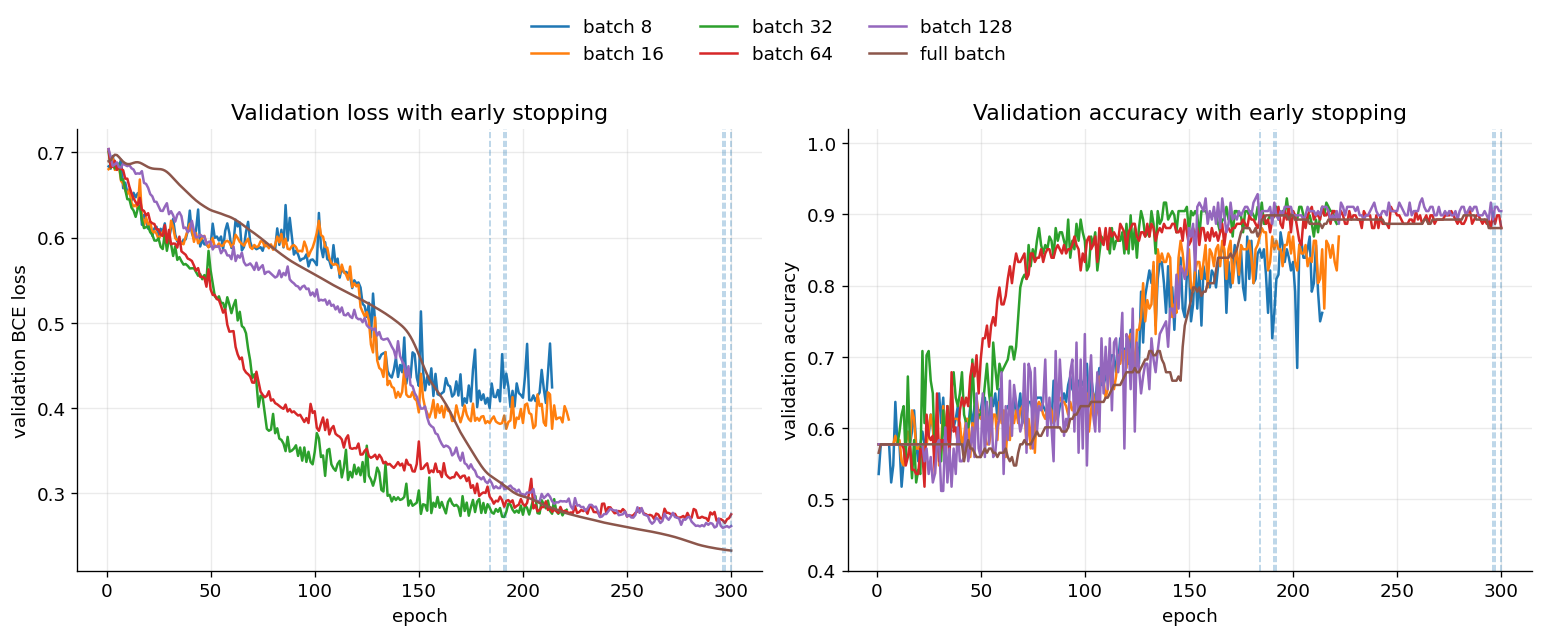

In [269]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

for label, result in results.items():
    history = result["history"]
    best = result["best"]
    axes[0].plot(history["epoch"], history["val_loss"], label=label)
    axes[0].axvline(best["epoch"], linestyle="--", linewidth=1, alpha=0.35)
    axes[1].plot(history["epoch"], history["val_acc"], label=label)
    axes[1].axvline(best["epoch"], linestyle="--", linewidth=1, alpha=0.35)

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("validation BCE loss")
axes[0].set_title("Validation loss with early stopping")

axes[1].set_xlabel("epoch")
axes[1].set_ylabel("validation accuracy")
axes[1].set_ylim(0.4, 1.02)
axes[1].set_title("Validation accuracy with early stopping")

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.03))
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


## Generalization gap at the selected checkpoint

Another useful diagnostic is the gap between validation loss and training loss:

$$
\text{generalization gap} = \mathcal{L}_{\mathrm{val}} - \mathcal{L}_{\mathrm{train}}.
$$

A large positive gap means the model is doing much better on the data it trains on than on held-out data. That is one sign of overfitting.


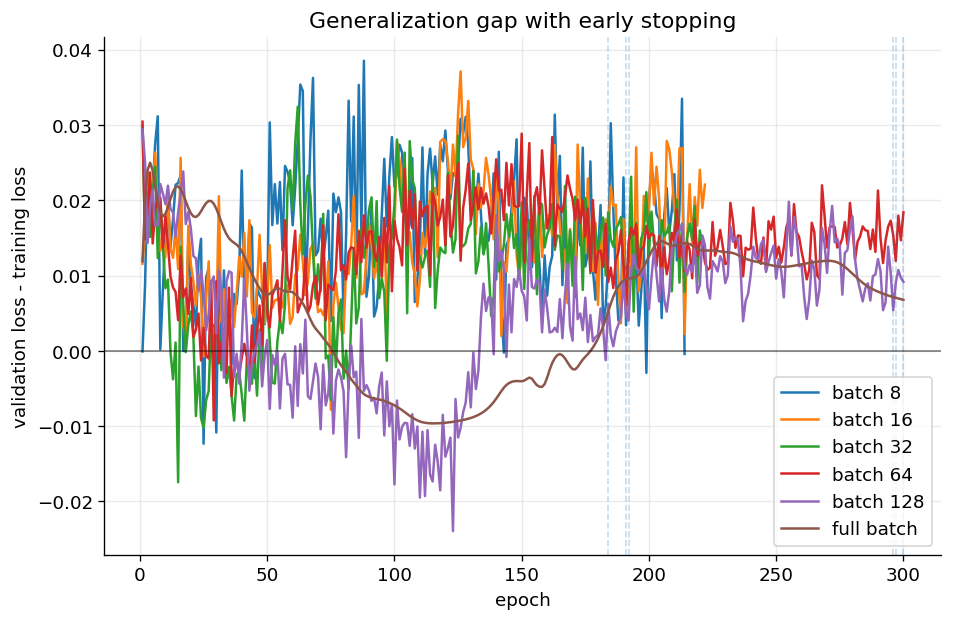

In [270]:
plt.figure(figsize=(9, 5.6))
for label, result in results.items():
    history = result["history"]
    gap = np.array(history["val_loss"]) - np.array(history["train_loss"])
    plt.plot(history["epoch"], gap, label=label)
    plt.axvline(result["best"]["epoch"], linestyle="--", linewidth=1, alpha=0.25)

plt.axhline(0.0, color="black", linewidth=1, alpha=0.5)
plt.xlabel("epoch")
plt.ylabel("validation loss - training loss")
plt.title("Generalization gap with early stopping")
plt.legend(loc="best")
plt.show()


## Viewed by parameter update

Epochs are not the whole story. Smaller batches make more parameter updates per epoch, so they often travel farther along the update axis before early stopping.

This plot is the direct analogue of the parameter-update plot from the linear-regression notebook, but here we show **validation loss** because model selection is based on held-out performance.

Curves terminate at different update counts because early stopping and updates-per-epoch both depend on batch size.


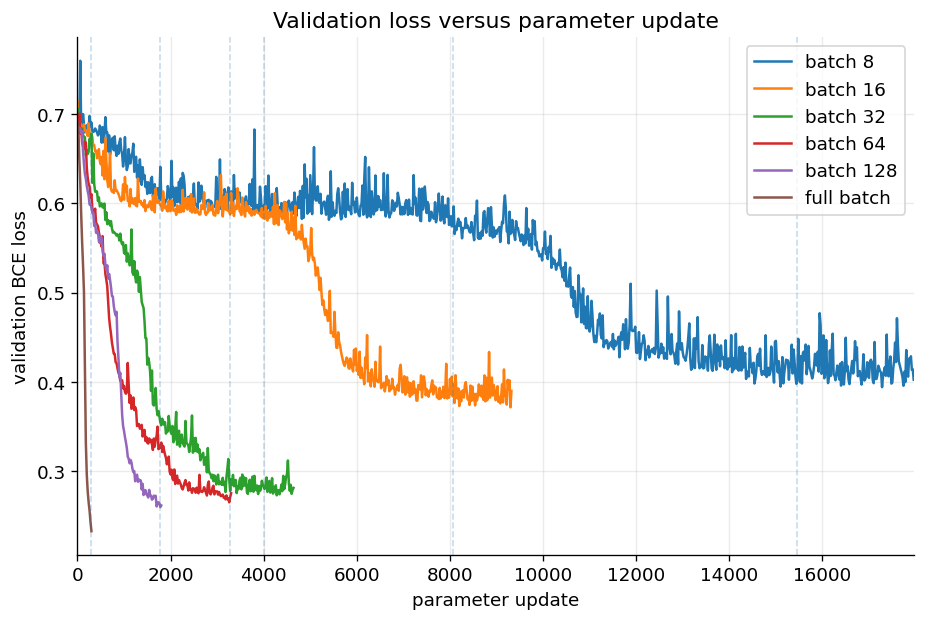

Maximum update count: 17976
   batch 8: stopped after 17976 updates; best update 15456
  batch 16: stopped after 9324 updates; best update 8064
  batch 32: stopped after 4641 updates; best update 4011
  batch 64: stopped after 3300 updates; best update 3267
 batch 128: stopped after 1800 updates; best update 1776
full batch: stopped after 300 updates; best update 300


In [271]:
max_updates = max(result["history"]["epoch_update"][-1] for result in results.values())

plt.figure(figsize=(9, 5.6))

for label, result in results.items():
    history = result["history"]
    plt.plot(history["update"], history["update_val_loss"], label=label)
    plt.axvline(result["best"]["update"], linestyle="--", linewidth=1, alpha=0.25)

plt.xlim(0, max_updates)
plt.xlabel("parameter update")
plt.ylabel("validation BCE loss")
plt.title("Validation loss versus parameter update")
plt.legend(loc="best")
plt.show()

print(f"Maximum update count: {max_updates}")
for label, result in results.items():
    history = result["history"]
    print(f"{label:>10s}: stopped after {history['epoch_update'][-1]} updates; best update {result['best']['update']}")


## Decision boundaries of the selected models

Each panel shows the decision boundary from the best validation-loss checkpoint for one batch size.

This is the visual test of the table above: the selected model should capture the ring shape without chasing too many individual training points.


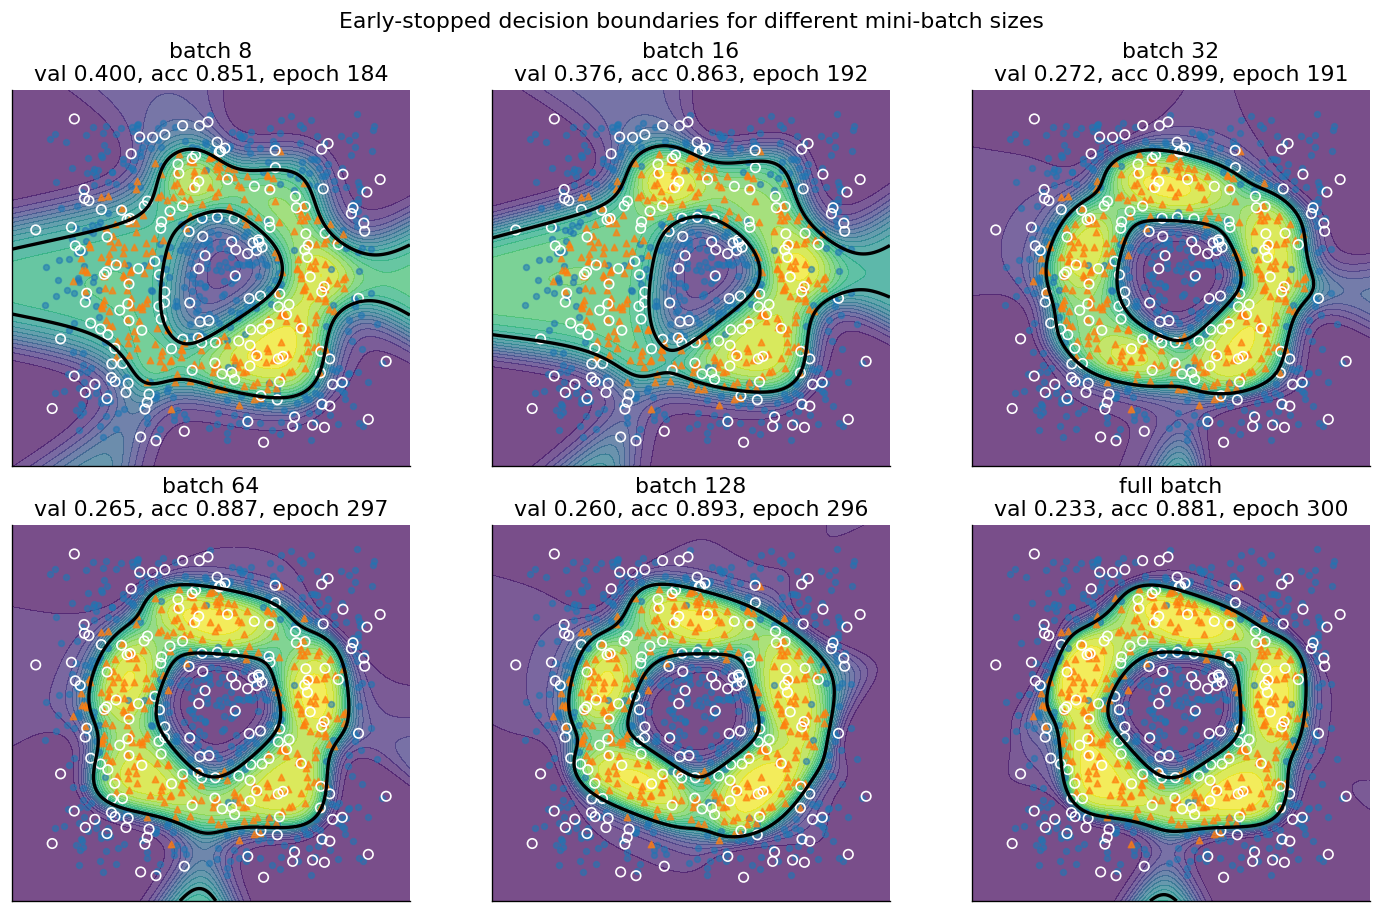

In [272]:
def probability_grid(model, X_data):
    x1_min, x1_max = X_data[:, 0].min().item() - 0.2, X_data[:, 0].max().item() + 0.2
    x2_min, x2_max = X_data[:, 1].min().item() - 0.2, X_data[:, 1].max().item() + 0.2
    x1_grid = torch.linspace(x1_min, x1_max, 180)
    x2_grid = torch.linspace(x2_min, x2_max, 180)
    XX, YY = torch.meshgrid(x1_grid, x2_grid, indexing="xy")
    grid_points = torch.stack([XX.reshape(-1), YY.reshape(-1)], dim=1)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(grid_points).squeeze(-1)).reshape(XX.shape)
    return XX, YY, probs


def plot_decision_boundary(ax, model, title):
    XX, YY, probs = probability_grid(model, X_ring)
    ax.contourf(XX.numpy(), YY.numpy(), probs.numpy(), levels=20, cmap="viridis", alpha=0.72)
    ax.contour(XX.numpy(), YY.numpy(), probs.numpy(), levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], s=12, alpha=0.55)
    ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], s=14, alpha=0.70, marker="^")
    ax.scatter(X_val[:, 0], X_val[:, 1], s=32, facecolors="none", edgecolors="white", linewidths=1.0)
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])


fig, axes = plt.subplots(2, 3, figsize=(12, 7.5), constrained_layout=True)
for ax, (label, result) in zip(axes.flat, results.items()):
    best = result["best"]
    title = f"{label}\nval {best['val_loss']:.3f}, acc {best['val_acc']:.3f}, epoch {best['epoch']}"
    plot_decision_boundary(ax, result["model"], title)

fig.suptitle("Early-stopped decision boundaries for different mini-batch sizes")
plt.show()


## Learning rate and batch size interact

Batch size should not be tuned completely separately from learning rate. A learning rate that works well for full-batch training may be too small or too large for a noisy small-batch run.

To see this interaction clearly, we sweep across both axes — batch size $\in \{8, 32, \text{full}\}$ and learning rate from a conservative $0.01$ up to an aggressive $1.0$ — and use early stopping for model selection at every cell. The wide LR range matters: only the safe side of the axis would let one batch size quietly win at every setting. Pushing higher exposes where the batch-size tradeoff actually bites.

The expectation from textbook intuition:

- **small batches** should fail first as LR rises, because their gradient estimates are noisier and large steps amplify that noise,
- **full batch** should hold up longest, because its gradient is the true training gradient and only the step size is risky.

If we never see that pattern, that itself is a finding worth noting (see the AdamW remark below).


In [273]:
high_learning_rates = [0.01, 0.03, 0.08, 0.15, 0.3, 0.6, 1.0]
sweep_batch_sizes = [8, 32, None]

# Raise max_epochs so every run gets a chance to early-stop on patience
# rather than hitting the budget. We flag any run that still truncates,
# so the reader can tell which numbers reflect a validation-selected
# checkpoint and which reflect a budget cutoff.
lr_max_epochs = 2000
lr_patience = 25

sweep_results = []

print("batch          lr    best val loss   best val acc   best epoch   stopped epoch   early-stopped?")
print("-----       -----    -------------   ------------   ----------   -------------   --------------")
for batch_size in sweep_batch_sizes:
    label = labels.get(batch_size, f"batch {batch_size}")
    for lr in high_learning_rates:
        _, history, best = train_with_batch_size(
            batch_size,
            max_epochs=lr_max_epochs,
            patience=lr_patience,
            min_delta=1e-4,
            lr=lr,
            model_seed=123,
            shuffle_seed=3000,
        )
        if best["state_dict"] is None or not math.isfinite(best["val_loss"]):
            print(f"{label:>10s}   {lr:5.2f}    diverged (no finite checkpoint)")
            continue
        stopped_epoch = history["epoch"][-1]
        early_stopped = stopped_epoch < lr_max_epochs
        flag = "yes" if early_stopped else "NO (hit max_epochs)"
        print(
            f"{label:>10s}   {lr:5.2f}    {best['val_loss']:13.3f}   {best['val_acc']:12.3f}   "
            f"{best['epoch']:10d}   {stopped_epoch:13d}   {flag}"
        )
        sweep_results.append({
            "label": label,
            "lr": lr,
            "val_loss": best["val_loss"],
            "val_acc": best["val_acc"],
        })

best_by_loss = min(sweep_results, key=lambda r: r["val_loss"])
best_by_acc = max(sweep_results, key=lambda r: r["val_acc"])

print()
print(f"Best by validation loss:     {best_by_loss['label']:>10s} at lr {best_by_loss['lr']:.2f}  "
      f"(val loss {best_by_loss['val_loss']:.3f}, val acc {best_by_loss['val_acc']:.3f})")
print(f"Best by validation accuracy: {best_by_acc['label']:>10s} at lr {best_by_acc['lr']:.2f}  "
      f"(val loss {best_by_acc['val_loss']:.3f}, val acc {best_by_acc['val_acc']:.3f})")


batch          lr    best val loss   best val acc   best epoch   stopped epoch   early-stopped?
-----       -----    -------------   ------------   ----------   -------------   --------------
   batch 8    0.01            0.381          0.875          302             327   yes
   batch 8    0.03            0.393          0.839          187             212   yes
   batch 8    0.08            0.408          0.869           43              68   yes
   batch 8    0.15            0.360          0.863           49              74   yes
   batch 8    0.30            0.460          0.827           42              67   yes
   batch 8    0.60            0.537          0.762           32              57   yes
   batch 8    1.00            0.818          0.548           11              36   yes
  batch 32    0.01            0.274          0.905          440             465   yes
  batch 32    0.03            0.268          0.911          283             308   yes
  batch 32    0.08            0.28

## A note on AdamW

The folklore that *medium mini-batches are best* comes mostly from training with plain SGD. Two things make that intuition load-bearing in the SGD setting:

1. mini-batch noise acts as an implicit regularizer that helps generalization,
2. the usable learning rate depends strongly on batch size, because every parameter shares one global step size.

**AdamW changes this picture.** It maintains running estimates of each parameter's gradient mean and variance, and uses them to scale that parameter's step size individually. That adaptive scaling absorbs a lot of the variance that mini-batching is traditionally there to manage. As a result, AdamW is much more forgiving of full-batch training than plain SGD is.

So for a small, clean problem like this ring dataset, the honest finding from these experiments is:

$$
\text{with AdamW on a small clean problem, full batch is fine — often better.}
$$

The mini-batch advantage becomes more visible when any of the following are true: the optimizer is plain SGD (or SGD + momentum), the dataset is noisier or much larger, the model is much bigger, or the training set is large enough that full-batch updates are simply infeasible per step. Treat the practical rule of thumb below in that light — it is good default advice for the regimes where it was formed, not a universal law derived from this notebook alone.


## Optional: repeat with several random seeds

One run can be misleading. Neural-network training depends on random initialization and mini-batch order, so the winners reported above could shift across seeds.

The two main candidates from the previous sections are **batch 32** (best by validation accuracy) and **full batch** (best by validation loss). We now rerun just those two, across several seeds, with proper early stopping rather than a fixed epoch budget. For each seed we report the validation-selected checkpoint; across seeds we report mean and standard deviation.


In [276]:
# (model_seed, shuffle_seed) pairs. The first pair is the one used in the
# single-seed LR sweep above, so we can see exactly how that run sits inside
# the multi-seed distribution.
repeat_seed_pairs = [
    (123, 3000),
    (101, 10_101),
    (202, 10_202),
    (303, 10_303),
    (404, 10_404),
    (505, 10_505),
]
repeat_batch_sizes = [32, None]
repeat_learning_rates = high_learning_rates  # same LR range as the previous table
repeat_max_epochs = 2000
repeat_patience = 25

seed_rows = []

for batch_size in repeat_batch_sizes:
    label = labels.get(batch_size, f"batch {batch_size}")
    for lr in repeat_learning_rates:
        best_losses = []
        best_accs = []
        best_updates = []
        truncated = 0

        for model_seed, shuffle_seed in repeat_seed_pairs:
            _, history, best = train_with_batch_size(
                batch_size,
                max_epochs=repeat_max_epochs,
                patience=repeat_patience,
                min_delta=1e-4,
                lr=lr,
                model_seed=model_seed,
                shuffle_seed=shuffle_seed,
            )
            best_losses.append(best["val_loss"])
            best_accs.append(best["val_acc"])
            best_updates.append(best["update"])
            if history["epoch"][-1] >= repeat_max_epochs:
                truncated += 1

        seed_rows.append((
            label,
            lr,
            float(np.mean(best_losses)),
            float(np.std(best_losses)),
            float(np.mean(best_accs)),
            float(np.std(best_accs)),
            float(np.mean(best_updates)),
            truncated,
        ))

print("batch          lr    best val loss mean +/- std     best val acc mean +/- std     mean best update     truncated")
print("-----       -----    -------------------------     ------------------------     ----------------     ---------")
for label, lr, loss_mean, loss_std, acc_mean, acc_std, update_mean, truncated in seed_rows:
    print(
        f"{label:>10s}   {lr:5.2f}    {loss_mean:8.3f} +/- {loss_std:6.3f}        "
        f"{acc_mean:8.3f} +/- {acc_std:6.3f}        "
        f"{update_mean:16.1f}     {truncated:>2d} / {len(repeat_seed_pairs)}"
    )

best_loss_row = min(seed_rows, key=lambda r: r[2])
best_acc_row = max(seed_rows, key=lambda r: r[4])
print()
print(f"Best by mean validation loss:     {best_loss_row[0]:>10s} at lr {best_loss_row[1]:.2f}  "
      f"(loss {best_loss_row[2]:.3f} +/- {best_loss_row[3]:.3f}, acc {best_loss_row[4]:.3f} +/- {best_loss_row[5]:.3f})")
print(f"Best by mean validation accuracy: {best_acc_row[0]:>10s} at lr {best_acc_row[1]:.2f}  "
      f"(loss {best_acc_row[2]:.3f} +/- {best_acc_row[3]:.3f}, acc {best_acc_row[4]:.3f} +/- {best_acc_row[5]:.3f})")


batch          lr    best val loss mean +/- std     best val acc mean +/- std     mean best update     truncated
-----       -----    -------------------------     ------------------------     ----------------     ---------
  batch 32    0.01       0.264 +/-  0.008           0.903 +/-  0.007                 10577.0      0 / 6
  batch 32    0.03       0.284 +/-  0.027           0.906 +/-  0.015                  4511.5      0 / 6
  batch 32    0.08       0.283 +/-  0.005           0.896 +/-  0.014                  2684.5      0 / 6
  batch 32    0.15       0.295 +/-  0.011           0.897 +/-  0.014                  1519.0      0 / 6
  batch 32    0.30       0.309 +/-  0.012           0.895 +/-  0.020                   801.5      0 / 6
  batch 32    0.60       0.364 +/-  0.032           0.859 +/-  0.031                   864.5      0 / 6
  batch 32    1.00       0.490 +/-  0.034           0.725 +/-  0.041                   469.0      0 / 6
full batch    0.01       0.295 +/-  0.174       

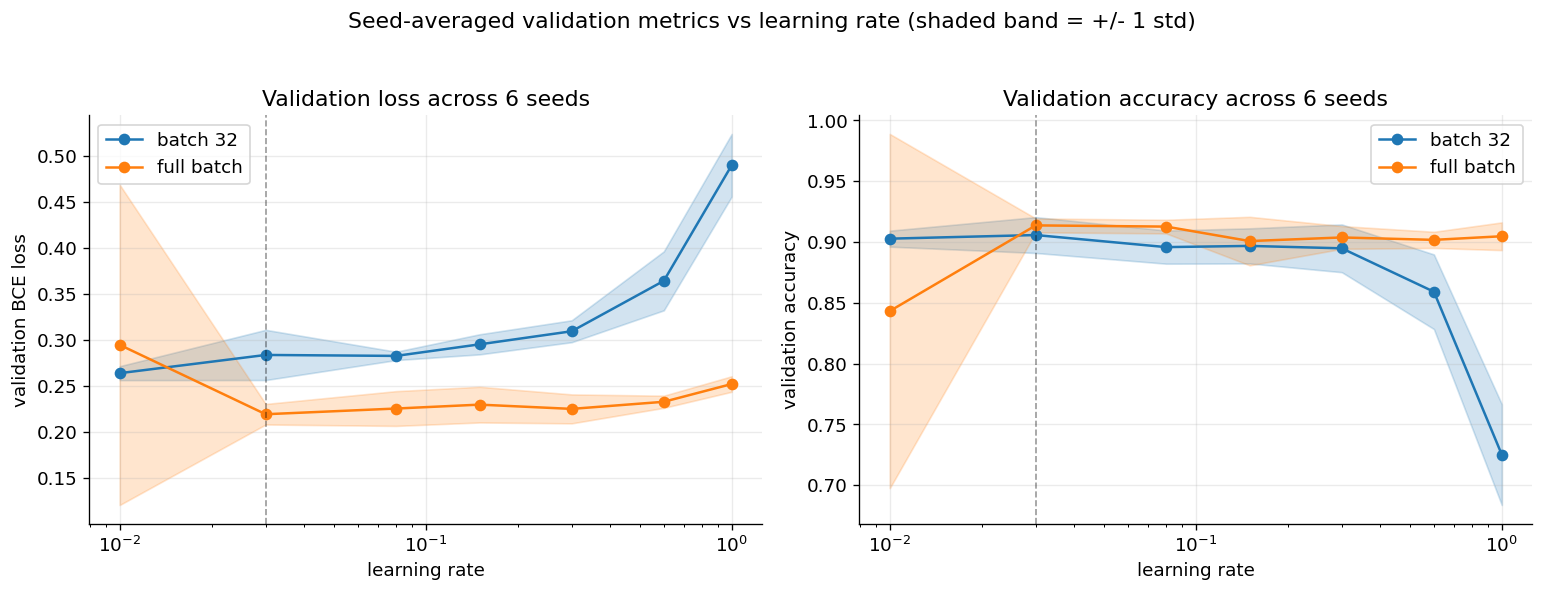

In [277]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))

for label in [labels.get(bs, f"batch {bs}") for bs in repeat_batch_sizes]:
    rows = [r for r in seed_rows if r[0] == label]
    lrs = np.array([r[1] for r in rows])
    loss_mean = np.array([r[2] for r in rows])
    loss_std = np.array([r[3] for r in rows])
    acc_mean = np.array([r[4] for r in rows])
    acc_std = np.array([r[5] for r in rows])

    line, = axes[0].plot(lrs, loss_mean, marker="o", label=label)
    axes[0].fill_between(lrs, loss_mean - loss_std, loss_mean + loss_std,
                         color=line.get_color(), alpha=0.2)

    line, = axes[1].plot(lrs, acc_mean, marker="o", label=label)
    axes[1].fill_between(lrs, acc_mean - acc_std, acc_mean + acc_std,
                         color=line.get_color(), alpha=0.2)

for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("learning rate")

axes[0].set_ylabel("validation BCE loss")
axes[0].set_title(f"Validation loss across {len(repeat_seed_pairs)} seeds")
axes[1].set_ylabel("validation accuracy")
axes[1].set_title(f"Validation accuracy across {len(repeat_seed_pairs)} seeds")

best_loss_lr = best_loss_row[1]
best_acc_lr = best_acc_row[1]
axes[0].axvline(best_loss_lr, linestyle="--", linewidth=1, color="black", alpha=0.4)
axes[1].axvline(best_acc_lr, linestyle="--", linewidth=1, color="black", alpha=0.4)

axes[0].legend(loc="best")
axes[1].legend(loc="best")
fig.suptitle("Seed-averaged validation metrics vs learning rate (shaded band = +/- 1 std)")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


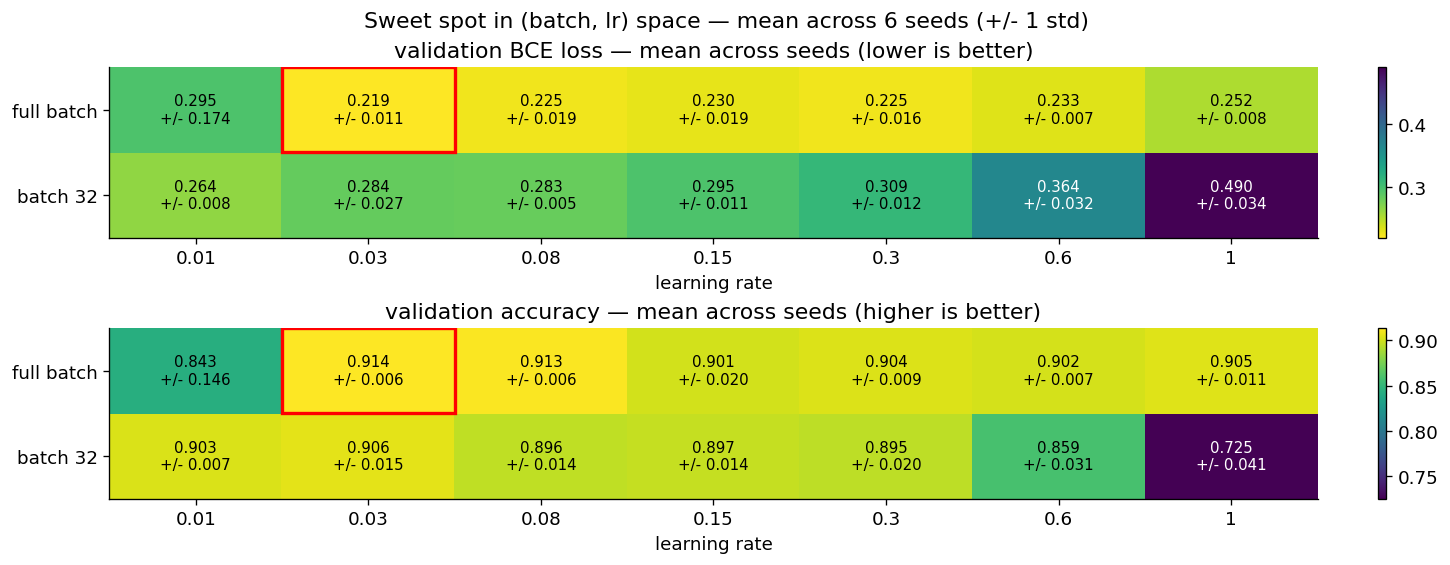

In [279]:
# Heatmap of the multi-seed sweep (seed_rows). Each cell is the mean across
# the 6 (model_seed, shuffle_seed) pairs, with std shown below the mean.
# Only batch 32 and full batch were swept, so the grid is 2 x 7.
heatmap_batch_labels = [labels.get(bs, f"batch {bs}") for bs in repeat_batch_sizes]
heatmap_lrs = sorted({r[1] for r in seed_rows})

loss_mean_grid = np.full((len(heatmap_batch_labels), len(heatmap_lrs)), np.nan)
loss_std_grid = np.full_like(loss_mean_grid, np.nan)
acc_mean_grid = np.full_like(loss_mean_grid, np.nan)
acc_std_grid = np.full_like(loss_mean_grid, np.nan)
for label, lr, loss_mean, loss_std, acc_mean, acc_std, *_ in seed_rows:
    i = heatmap_batch_labels.index(label)
    j = heatmap_lrs.index(lr)
    loss_mean_grid[i, j] = loss_mean
    loss_std_grid[i, j] = loss_std
    acc_mean_grid[i, j] = acc_mean
    acc_std_grid[i, j] = acc_std

fig, axes = plt.subplots(2, 1, figsize=(12, 4.6), constrained_layout=True)

im0 = axes[0].imshow(loss_mean_grid, aspect="auto", cmap="viridis_r", origin="lower")
axes[0].set_title("validation BCE loss — mean across seeds (lower is better)")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(acc_mean_grid, aspect="auto", cmap="viridis", origin="lower")
axes[1].set_title("validation accuracy — mean across seeds (higher is better)")
fig.colorbar(im1, ax=axes[1])

panels = [
    (axes[0], loss_mean_grid, loss_std_grid, True),   # loss: lower better
    (axes[1], acc_mean_grid, acc_std_grid, False),    # acc: higher better
]
for ax, mean_grid, std_grid, lower_is_better in panels:
    ax.set_xticks(range(len(heatmap_lrs)))
    ax.set_xticklabels([f"{lr:g}" for lr in heatmap_lrs])
    ax.set_yticks(range(len(heatmap_batch_labels)))
    ax.set_yticklabels(heatmap_batch_labels)
    ax.set_xlabel("learning rate")
    ax.grid(False)
    midpoint = 0.5 * (np.nanmin(mean_grid) + np.nanmax(mean_grid))
    for i in range(mean_grid.shape[0]):
        for j in range(mean_grid.shape[1]):
            mean = mean_grid[i, j]
            std = std_grid[i, j]
            if np.isnan(mean):
                continue
            text_dark = (mean > midpoint) if lower_is_better else (mean < midpoint)
            color = "white" if text_dark else "black"
            ax.text(j, i, f"{mean:.3f}\n+/- {std:.3f}", ha="center", va="center",
                    color=color, fontsize=9)

# Mark optimum cells
i_loss, j_loss = np.unravel_index(np.nanargmin(loss_mean_grid), loss_mean_grid.shape)
i_acc, j_acc = np.unravel_index(np.nanargmax(acc_mean_grid), acc_mean_grid.shape)
axes[0].add_patch(plt.Rectangle((j_loss - 0.5, i_loss - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=2))
axes[1].add_patch(plt.Rectangle((j_acc - 0.5, i_acc - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=2))

fig.suptitle(f"Sweet spot in (batch, lr) space — mean across {len(repeat_seed_pairs)} seeds (+/- 1 std)")
plt.show()


## Practical rule of thumb

For this kind of small MLP, a medium mini-batch such as 16, 32, or 64 is usually a sensible starting point.

But the notebook's decision rule is not "medium batches are always best." The rule is:

1. train each candidate with the same early-stopping protocol,
2. choose the checkpoint with the best validation loss,
3. compare the selected checkpoints across batch sizes.

In larger projects, batch size is chosen by balancing optimization behavior, generalization, and hardware efficiency.


## Summary

Mini-batch size affects the final selected model because it changes the path taken by optimization.

Key lessons:

| Concept | Meaning |
|---|---|
| batch size | number of training examples used in one gradient update |
| updates per epoch | smaller batches make more updates per pass through the data |
| early stopping | selects the checkpoint with the best validation loss |
| validation loss | primary model-selection criterion in this notebook |
| validation accuracy | useful second metric for hard classification |

The important comparison is not "who wins after a fixed number of epochs?" The important comparison is:

$$
\text{Which batch size gives the best validation-selected model?}
$$


## Exercises

1. Change `patience` from `30` to `10` or `60`. Which batch sizes are most sensitive?

2. Try `batch_size = 1`. Does stochastic training improve validation loss, or does it become too noisy?

3. Remove `weight_decay=0.01` inside `train_with_batch_size`. Does early stopping alone control overfitting?

4. Increase `Nneurons` in `make_mlp`. Does the best batch size change?

5. Repeat the experiment with a different `model_seed`. Are the conclusions exactly the same?
